# Deep Learning Analysis: Traffic Sign Classification
## Three-Class Safety-Critical Recognition — Multi-Source Dataset Experiment

---

## 1. Problem Definition

**Scientific Question:** Can shallow and deep CNNs reliably distinguish **stop**, **yield**, and **do-not-enter** signs when trained on data pooled from multiple real-world sources with significant domain gaps?

### Why These Three Classes?
These are the three highest-stakes signs for autonomous vehicles:
- **Stop** — failure to stop causes collisions; no partial credit
- **Yield** — missed yields produce right-of-way violations
- **Do-Not-Enter** — entering a one-way road causes head-on collisions

Restricting to 3 classes allows per-class AUC-ROC analysis that is meaningful at inference time.

### Datasets Used
| Dataset | Source Type | 3-Class Samples (est.) |
|---------|-------------|------------------------|
| DOT | US canonical reference (1 image/class) | ~3 |
| GTSRB | German benchmark, Kaggle CSV + ROI crops | ~6,000 |
| LISA | US traffic video frame crops | varies |
| BDD100K (extracted) | Dashcam crops, ResNet-10 DANN labels | ~502 |

### Models Compared
| Model | Architecture | Input | Pretrained |
|-------|-------------|-------|------------|
| **BasicCNN** | 2 conv layers, MaxPool×2, no BN | 30×30 | No |
| **ComplexCNN** | 4 conv blocks + BN + Dropout | 30×30 | No |
| **ResNet-50** | `torchvision` pretrained, FC replaced | 224×224 | ImageNet |

## 2. Requirements & Setup

```
torch>=2.0  torchvision>=0.15  scikit-learn>=1.3
matplotlib  seaborn  Pillow  numpy  pandas
```

**Training protocol:**
- BasicCNN / ComplexCNN: 20 epochs, Adam lr=1e-3, CrossEntropyLoss
- ResNet-50: 10 epochs fine-tuning, differential LR (backbone 1e-5, FC 1e-3), CosineAnnealingLR
- Seeds fixed for `random`, `numpy`, `torch` — reproducible runs

In [1]:
# ⚠️  IMPORTANT: After this cell completes, RESTART THE KERNEL before running cell 3+
# This installs PyTorch with CUDA 13.0 support (required for NVIDIA Blackwell GB10 / SM 12.1)
# !pip uninstall torch torchvision torchaudio -y
# !pip install torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu130
# !pip install matplotlib seaborn
# print("\n✅ PyTorch cu130 installed. NOW RESTART THE KERNEL (Kernel → Restart Kernel).")


In [2]:
import os
import sys
import random
import time
import json
import warnings
from pathlib import Path
from statistics import mean
from collections import Counter

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, ConcatDataset, random_split
from torchvision import transforms
import torchvision.models as tv_models

from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import label_binarize

from data.datasets import DOTDataset, GTSRBDataset, LISADataset, BDD100KDataset
from utils.config import DATA_DIR, CHECKPOINT_DIR
from utils.device import get_device

# Safe device detection — falls back to CPU if CUDA kernel image unavailable
# (e.g. NVIDIA Blackwell SM 12.1 with CUDA 12.x PyTorch)
def _get_safe_device():
    import torch
    if torch.cuda.is_available():
        try:
            _t = torch.zeros(1, device='cuda')
            _   = _t + _t   # triggers kernel load
            return torch.device('cuda')
        except RuntimeError as e:
            print(f'WARNING: CUDA unavailable ({e})')
            print('  → Fix: restart the kernel after cell 0 (pip install cu130) runs.')
            print('  → Falling back to CPU.')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')

device = _get_safe_device()
print(f'Device  : {device}')
print(f'PyTorch : {torch.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu130


In [23]:
# ------------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------------
SEED        = 42
BATCH_SIZE  = 32
NUM_WORKERS = 0
NUM_CLASSES = 3

# DOT label → 3-class index  (stop=0, yield=1, donotenter=18)
DOT_TO_3    = {0: 0, 1: 1, 18: 2}
CLASS_NAMES = ['stop', 'yield', 'donotenter']
COLORS      = ['#E74C3C', '#F39C12', '#3498DB']
model_colors = {'BasicCNN': COLORS[0], 'ComplexCNN': COLORS[1], 'ResNet-50': COLORS[2]}

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print('Seed:', SEED, '| Classes:', CLASS_NAMES)

Seed: 42 | Classes: ['stop', 'yield', 'donotenter']


## 3. Model Definitions

### Spatial dimension walkthrough

**BasicCNN** (30×30 input, no padding):
- `conv1` 3×3 → 32×28×28 → pool → 32×14×14
- `conv2` 3×3 → 64×12×12 → pool → 64×**6×6**
- `fc1`: 64×6×6 = **2304** features

**ComplexCNN** (30×30 input, padding=1 preserves size):
- Block 1 + pool → 32×15×15
- Block 2 + pool → 64×7×7
- Block 3 + pool → 128×3×3
- Block 4 + pool → 256×**1×1**
- `fc1`: 256×1×1 = **256** features

**ResNet-50**: torchvision ImageNet pretrained. Final `fc` layer replaced: 2048 → 3.

In [4]:
# ------------------------------------------------------------------
# BasicCNN  —  2 conv layers, MaxPool×2, no BatchNorm  (30×30)
# ------------------------------------------------------------------
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 6 * 6, 128)
        self.fc2   = nn.Linear(128, NUM_CLASSES)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

    def extract_features(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        return torch.relu(self.fc1(torch.flatten(x, 1)))  # 128-d


# ------------------------------------------------------------------
# ComplexCNN  —  4 conv blocks + BatchNorm + Dropout  (30×30)
# ------------------------------------------------------------------
class ComplexCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,   32,  3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,  64,  3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,  128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)
        self.pool  = nn.MaxPool2d(2, 2)
        self.drop  = nn.Dropout(0.25)
        self.fc1   = nn.Linear(256 * 1 * 1, 256)
        self.fc2   = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.drop(self.pool(torch.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(torch.relu(self.bn2(self.conv2(x)))))
        x = self.drop(self.pool(torch.relu(self.bn3(self.conv3(x)))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

    def extract_features(self, x):
        x = self.drop(self.pool(torch.relu(self.bn1(self.conv1(x)))))
        x = self.drop(self.pool(torch.relu(self.bn2(self.conv2(x)))))
        x = self.drop(self.pool(torch.relu(self.bn3(self.conv3(x)))))
        x = self.pool(torch.relu(self.bn4(self.conv4(x))))
        return torch.relu(self.fc1(torch.flatten(x, 1)))  # 256-d


# ------------------------------------------------------------------
# ResNet-50  —  ImageNet pretrained, FC head replaced  (224×224)
# ------------------------------------------------------------------
def build_resnet50():
    model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


for name, m in [('BasicCNN', BasicCNN()), ('ComplexCNN', ComplexCNN()),
                ('ResNet-50', build_resnet50())]:
    tot, tr = count_params(m)
    print(f'{name:<12}: {tot:>12,} total  |  {tr:>12,} trainable')

BasicCNN    :      314,819 total  |       314,819 trainable
ComplexCNN  :      455,939 total  |       455,939 trainable
ResNet-50   :   23,514,179 total  |    23,514,179 trainable


## 4. Data Loading

### Design
All raw datasets are loaded with `transform=None` so `__getitem__` returns PIL images (after ROI/bbox crop).  A `FilteredSubset` wrapper:
1. Keeps only samples with DOT labels in `{0 (stop), 1 (yield), 18 (donotenter)}`
2. Remaps to `{0, 1, 2}`
3. Applies the model-specific transform at read time

This lets the same filtered index list feed all three models with different resolutions.

In [5]:
# ------------------------------------------------------------------
# FilteredSubset  —  3-class filter + label remap + transform
# Images are cached in RAM at init time to eliminate per-epoch
# disk I/O (30×30 dataset ≈ 16 MB; trivial to hold in memory).
# ------------------------------------------------------------------
class FilteredSubset(Dataset):
    def __init__(self, base, valid_labels, label_map, transform,
                 cache=True):
        self.transform = transform
        self.indices   = [i for i, (_, l) in enumerate(base.samples)
                          if l in valid_labels]
        self.labels    = [label_map[base.samples[i][1]] for i in self.indices]

        # Pre-load all PIL images into RAM — eliminates file I/O every epoch
        if cache:
            self._cache = []
            for idx in self.indices:
                img, _ = base[idx]      # returns PIL Image (base transform=None)
                self._cache.append(img)
        else:
            self._cache = None
            self._base  = base

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img = self._cache[idx] if self._cache is not None else self._base[self.indices[idx]][0]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ------------------------------------------------------------------
# Transforms
# ------------------------------------------------------------------
_NORM = dict(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

tf_train_30 = transforms.Compose([
    transforms.Resize((30, 30)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_eval_30 = transforms.Compose([
    transforms.Resize((30, 30)),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_train_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])
tf_eval_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(**_NORM),
])

print('Transforms ready — 30×30 (BasicCNN / ComplexCNN)  |  224×224 (ResNet-50)')
print('FilteredSubset: PIL images cached in RAM at init time')


Transforms ready — 30×30 (BasicCNN / ComplexCNN)  |  224×224 (ResNet-50)
FilteredSubset: PIL images cached in RAM at init time


In [6]:
# ------------------------------------------------------------------
# Load raw datasets  (transform=None → PIL Image from __getitem__)
# ------------------------------------------------------------------
raw_datasets = []   # [(name, raw_ds), ...]

# DOT
dot_root = DATA_DIR / 'DOT'
if dot_root.exists():
    dot_raw = DOTDataset(dot_root, transform=None)
    n = sum(1 for _, l in dot_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('DOT', dot_raw))
    print(f'DOT      : {len(dot_raw):5d} total  →  {n} match 3-class filter')
else:
    print(f'DOT: not found at {dot_root}')

# GTSRB
gtsrb_root = DATA_DIR / 'gtsrb'
if not gtsrb_root.exists():
    gtsrb_root = DATA_DIR / 'gtsrb-german-traffic-sign'
gtsrb_train_raw = gtsrb_test_raw = None
if gtsrb_root.exists():
    gtsrb_train_raw = GTSRBDataset(gtsrb_root, transform=None,
                                    split='train', dot_only=True)
    gtsrb_test_raw  = GTSRBDataset(gtsrb_root, transform=None,
                                    split='test',  dot_only=True)
    n_tr = sum(1 for _, l in gtsrb_train_raw.samples if l in DOT_TO_3)
    n_te = sum(1 for _, l in gtsrb_test_raw.samples  if l in DOT_TO_3)
    raw_datasets.append(('GTSRB_train', gtsrb_train_raw))
    raw_datasets.append(('GTSRB_test',  gtsrb_test_raw))
    print(f'GTSRB    : {len(gtsrb_train_raw):5d} train + {len(gtsrb_test_raw):4d} test  '
          f'→  {n_tr} train / {n_te} test (3-class)')
else:
    print(f'GTSRB: not found at {gtsrb_root}')

# LISA
lisa_base = DATA_DIR / 'lisa'
lisa_dir  = (lisa_base / 'extracted' if (lisa_base / 'extracted').exists() else
             lisa_base if (lisa_base / 'Annotations').exists() else None)
lisa_raw  = None
if lisa_dir:
    lisa_raw = LISADataset(lisa_dir, transform=None, domain_only=False)
    n = sum(1 for _, l in lisa_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('LISA', lisa_raw))
    print(f'LISA     : {len(lisa_raw):5d} total  →  {n} match 3-class filter')
else:
    print('LISA     : not available (skipping)')

# BDD100K extracted
extracted_root = PROJECT_ROOT / 'extracted'
bdd_raw = None
if (extracted_root / 'annotations.json').exists():
    bdd_raw = BDD100KDataset(extracted_root, transform=None,
                              annotation_file='annotations.json',
                              domain_only=False)
    n = sum(1 for _, l in bdd_raw.samples if l in DOT_TO_3)
    raw_datasets.append(('BDD100K', bdd_raw))
    print(f'BDD100K  : {len(bdd_raw):5d} total  →  {n} match 3-class filter')
else:
    print('BDD100K  : run data/extract_bdd100k_labels.py first')

DOT      :    43 total  →  3 match 3-class filter
GTSRB    :  6420 train + 2130 test  →  4050 train / 1350 test (3-class)
LISA     : 53562 total  →  53562 match 3-class filter
BDD100K  :   502 total  →  502 match 3-class filter


In [7]:
# ------------------------------------------------------------------
# Build train / val / test splits
# Class imbalance handled via WeightedRandomSampler on training set.
# Class weights for CrossEntropyLoss computed from training labels.
# ------------------------------------------------------------------
def build_loaders(tf_train, tf_eval, val_frac=0.15, test_frac=0.15,
                  batch_size=BATCH_SIZE):
    pool_raws = [(n, r) for n, r in raw_datasets if n != 'GTSRB_test']
    test_raws = [(n, r) for n, r in raw_datasets if n == 'GTSRB_test']

    pool_train = ConcatDataset([FilteredSubset(r, set(DOT_TO_3.keys()), DOT_TO_3, tf_train)
                                for _, r in pool_raws])
    pool_eval  = ConcatDataset([FilteredSubset(r, set(DOT_TO_3.keys()), DOT_TO_3, tf_eval)
                                for _, r in pool_raws])

    total   = len(pool_train)
    n_val   = max(1, int(total * val_frac))
    n_test  = max(1, int(total * test_frac))
    n_train = total - n_val - n_test

    gen  = torch.Generator().manual_seed(SEED)
    train_ds, _, _     = random_split(pool_train, [n_train, n_val, n_test], generator=gen)
    gen2 = torch.Generator().manual_seed(SEED)
    _, val_ds, test_ds = random_split(pool_eval,  [n_train, n_val, n_test], generator=gen2)

    # ── Class imbalance: collect training labels without loading images ──
    all_pool_labels = []
    for sub_ds in pool_train.datasets:
        all_pool_labels.extend(sub_ds.labels)
    all_pool_labels = np.array(all_pool_labels)
    train_labels    = all_pool_labels[list(train_ds.indices)]

    class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
    class_weights = (1.0 / np.maximum(class_counts, 1))
    class_weights /= class_weights.sum()          # normalise
    sample_weights = class_weights[train_labels]

    sampler = torch.utils.data.WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float),
        num_samples = len(train_labels),
        replacement = True,
    )
    # Expose class_weights tensor for weighted CrossEntropyLoss
    ce_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * np.maximum(class_counts, 1)),
                               dtype=torch.float)

    kw_base = dict(num_workers=NUM_WORKERS,
                   pin_memory=(device.type == 'cuda'),
                   persistent_workers=(NUM_WORKERS > 0),
                   prefetch_factor=4 if NUM_WORKERS > 0 else None)
    loaders = {
        'train':      DataLoader(train_ds, batch_size=batch_size,
                                 sampler=sampler, **kw_base),
        'val':        DataLoader(val_ds,   batch_size=batch_size,
                                 shuffle=False, **kw_base),
        'test':       DataLoader(test_ds,  batch_size=batch_size,
                                 shuffle=False, **kw_base),
        'ce_weights': ce_weights,
    }
    if test_raws:
        gtsrb_eval = FilteredSubset(test_raws[0][1], set(DOT_TO_3.keys()), DOT_TO_3, tf_eval)
        loaders['gtsrb_test'] = DataLoader(gtsrb_eval, batch_size=batch_size,
                                           shuffle=False, **kw_base)

    print(f'  Class counts (train): '
          + '  '.join(f'{CLASS_NAMES[i]}: {int(class_counts[i])}' for i in range(NUM_CLASSES)))
    print(f'  CE weights: ' + '  '.join(f'{CLASS_NAMES[i]}: {ce_weights[i]:.3f}'
                                         for i in range(NUM_CLASSES)))
    return loaders, (n_train, n_val, n_test)

RESNET_BATCH_SIZE = 256
set_seed()
loaders_30,  split_sizes = build_loaders(tf_train_30,  tf_eval_30)
loaders_224, _           = build_loaders(tf_train_224, tf_eval_224,
                                         batch_size=RESNET_BATCH_SIZE)

n_tr, n_val, n_te = split_sizes
print(f'Pool split → train: {n_tr}  val: {n_val}  test(holdout): {n_te}')
g = loaders_30.get('gtsrb_test')
print(f'GTSRB held-out test: {len(g.dataset) if g else 0} samples')


  Class counts (train): stop: 38080  yield: 1798  donotenter: 805
  CE weights: stop: 0.356  yield: 7.542  donotenter: 16.846
  Class counts (train): stop: 38080  yield: 1798  donotenter: 805
  CE weights: stop: 0.356  yield: 7.542  donotenter: 16.846
Pool split → train: 40683  val: 8717  test(holdout): 8717
GTSRB held-out test: 1350 samples


## 5. Exploratory Data Analysis

### What to look for
- **Class balance** across the combined training pool
- **Per-source contribution** — domain diversity
- **Visual quality differences** between GTSRB (clean crops) and BDD100K (noisy dashcam)

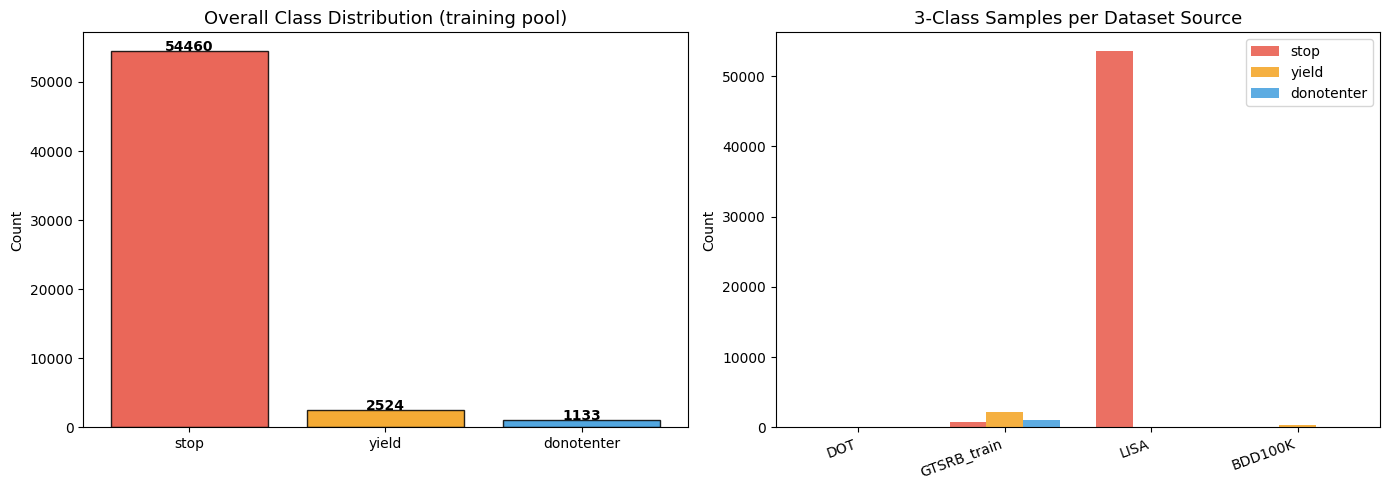


Source              stop    yield   donotenter    total
-------------------------------------------------------
DOT                    1        1            1        3
GTSRB_train          780     2160         1110     4050
LISA               53562        0            0    53562
BDD100K              117      363           22      502


In [8]:
# ------------------------------------------------------------------
# Class distribution — training pool + per-source breakdown
# ------------------------------------------------------------------
source_counts = {}
for src_name, raw_ds in raw_datasets:
    if src_name == 'GTSRB_test':
        continue
    cnt = Counter(CLASS_NAMES[DOT_TO_3[l]] for _, l in raw_ds.samples if l in DOT_TO_3)
    source_counts[src_name] = cnt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
overall = Counter()
for c in source_counts.values():
    overall.update(c)
bars = axes[0].bar(CLASS_NAMES, [overall[c] for c in CLASS_NAMES],
                   color=COLORS, edgecolor='black', alpha=0.85)
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(int(b.get_height())), ha='center', fontweight='bold')
axes[0].set_title('Overall Class Distribution (training pool)', fontsize=13)
axes[0].set_ylabel('Count')

# Per source
srcs = list(source_counts.keys())
x, w = np.arange(len(srcs)), 0.25
for i, cls in enumerate(CLASS_NAMES):
    axes[1].bar(x + i*w, [source_counts[s][cls] for s in srcs],
                w, label=cls, color=COLORS[i], alpha=0.8)
axes[1].set_xticks(x + w)
axes[1].set_xticklabels(srcs, rotation=20, ha='right')
axes[1].set_title('3-Class Samples per Dataset Source', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n{"Source":<15} {"stop":>8} {"yield":>8} {"donotenter":>12} {"total":>8}')
print('-' * 55)
for s, c in source_counts.items():
    print(f'{s:<15} {c["stop"]:>8} {c["yield"]:>8} {c["donotenter"]:>12} {sum(c.values()):>8}')

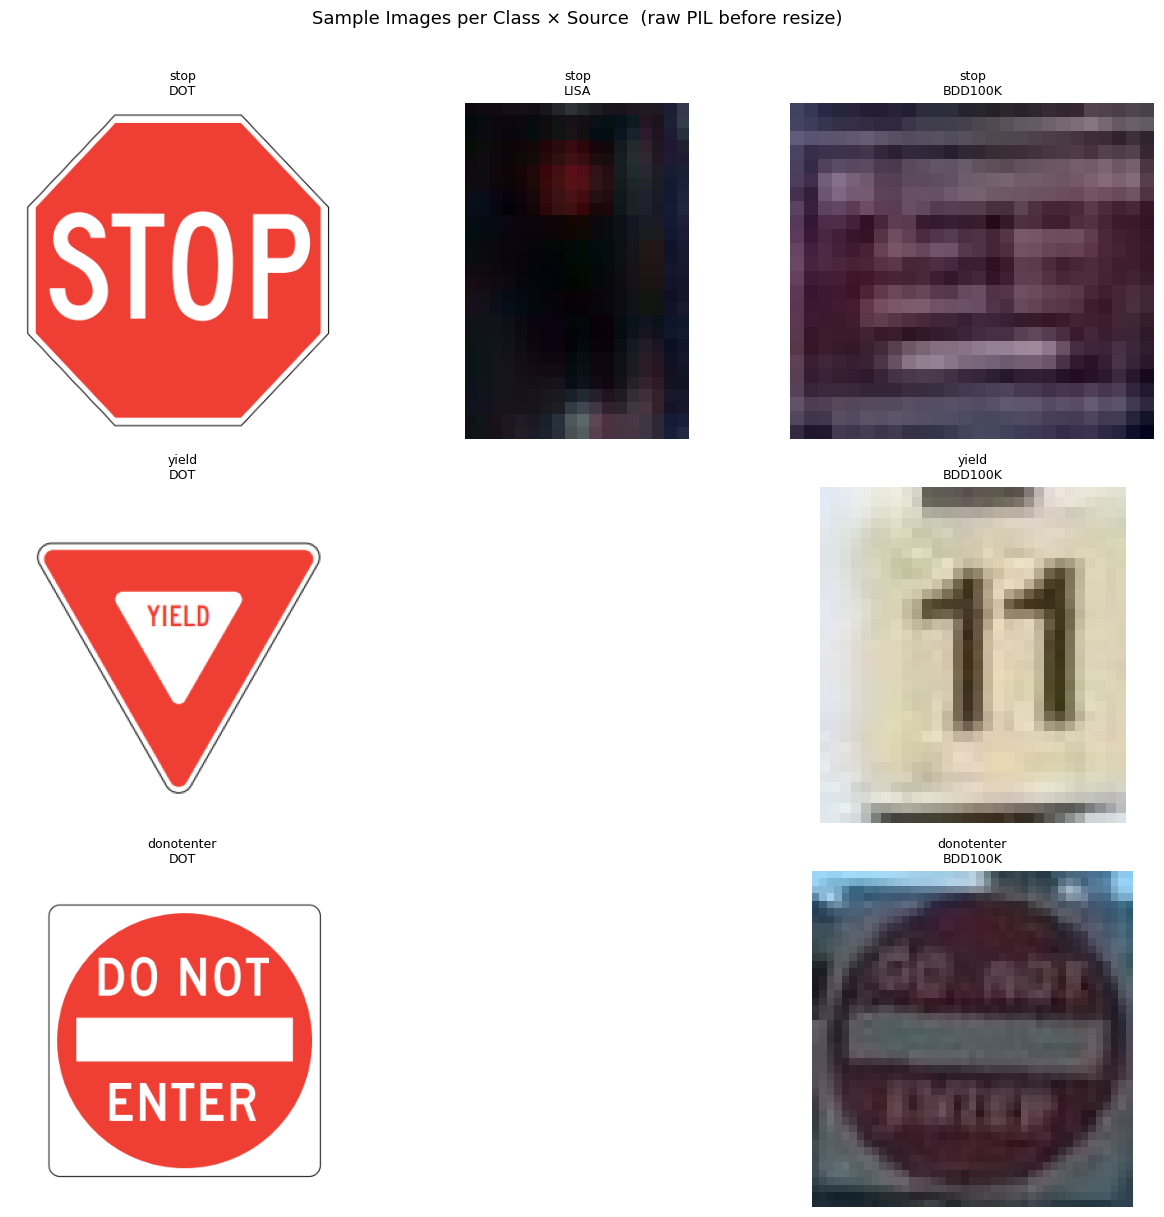

In [9]:
# ------------------------------------------------------------------
# Sample images grid — 1 per (class × source)
# ------------------------------------------------------------------
set_seed()
plot_srcs = [(n, r) for n, r in raw_datasets if n not in ('GTSRB_test', 'GTSRB_train')]
n_cols = len(plot_srcs)
fig, axes = plt.subplots(NUM_CLASSES, n_cols, figsize=(4*n_cols, 4*NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for col, (src_name, raw_ds) in enumerate(plot_srcs):
    for row, cls_name in enumerate(CLASS_NAMES):
        dot_lbl = [k for k, v in DOT_TO_3.items() if v == row][0]
        cands   = [i for i, (_, l) in enumerate(raw_ds.samples) if l == dot_lbl]
        ax = axes[row][col]
        if not cands:
            ax.axis('off')
            continue
        img, _ = raw_ds[random.choice(cands)]
        if isinstance(img, torch.Tensor):
            img = transforms.ToPILImage()(img)
        ax.imshow(img)
        ax.set_title(f'{cls_name}\n{src_name}', fontsize=9)
        ax.axis('off')

plt.suptitle('Sample Images per Class × Source  (raw PIL before resize)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6. Training

Each model trains on the same 70% pool split with the model-appropriate transform.  Validation accuracy is tracked per epoch.  Timing is measured to compare compute cost.

In [10]:
# ------------------------------------------------------------------
# Training utilities  (AMP, early stopping, weighted CE loss)
# ------------------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()
    tot_loss = correct = total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                out  = model(imgs)
                loss = criterion(out, lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
        tot_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return tot_loss / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    tot_loss = correct = total = 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            out  = model(imgs)
            loss = criterion(out, lbls)
        tot_loss += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return tot_loss / max(total, 1), correct / max(total, 1)


def run_training(model, loaders, optimizer, epochs,
                 scheduler=None, label='model', use_amp=False,
                 ckpt_dir=None, ckpt_name='best_model.pth',
                 patience=None, class_weights=None):
    """Train with AMP, early stopping, weighted CE loss, and checkpoint saving.

    Args:
        patience:       Stop after this many epochs with no val_acc improvement.
                        None = disabled.
        class_weights:  1-D tensor of per-class weights for CrossEntropyLoss.
                        Counters class imbalance. None = uniform.
    """
    ce_w      = class_weights.to(device) if class_weights is not None else None
    criterion = nn.CrossEntropyLoss(weight=ce_w)
    history   = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    ep_times  = []
    t_start   = time.time()
    best_val  = 0.0
    best_ep   = 0
    no_improv = 0

    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == 'cuda') else None
    if scaler:
        print(f'  [{label}] AMP enabled')
    if patience:
        print(f'  [{label}] Early stopping patience = {patience}')
    if ce_w is not None:
        print(f'  [{label}] Weighted CE loss')

    if ckpt_dir is not None:
        ckpt_dir = Path(ckpt_dir)
        ckpt_dir.mkdir(parents=True, exist_ok=True)
        print(f'  [{label}] Checkpoints → {ckpt_dir / ckpt_name}')

    for ep in range(1, epochs + 1):
        t0 = time.time()
        tr_l, tr_a = train_epoch(model, loaders['train'], optimizer, criterion, device, scaler)
        vl_l, vl_a = eval_epoch(model,  loaders['val'],   criterion, device)
        if scheduler:
            scheduler.step()

        history['train_loss'].append(tr_l)
        history['train_acc'].append(tr_a)
        history['val_loss'].append(vl_l)
        history['val_acc'].append(vl_a)
        ep_times.append(time.time() - t0)

        tag = ''
        if vl_a > best_val:
            best_val  = vl_a
            best_ep   = ep
            no_improv = 0
            if ckpt_dir is not None:
                torch.save({
                    'model_state_dict':     model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'epoch':                ep,
                    'best_value':           best_val,
                    'best_epoch':           best_ep,
                }, ckpt_dir / ckpt_name)
                tag = '  ← saved'
        else:
            no_improv += 1
            tag = f'  (no improve {no_improv}/{patience})' if patience else ''

        print(f'  [{label}] {ep:2d}/{epochs}  '
              f'loss {tr_l:.4f}  acc {tr_a:.4f}  '
              f'val_loss {vl_l:.4f}  val_acc {vl_a:.4f}  '
              f'({ep_times[-1]:.1f}s){tag}')

        if patience and no_improv >= patience:
            print(f'  [{label}] Early stop triggered at epoch {ep} '
                  f'(best val_acc {best_val:.4f} @ epoch {best_ep})')
            break

    total_time = time.time() - t_start
    print(f'  [{label}] DONE — best val_acc {best_val:.4f} @ epoch {best_ep}  '
          f'avg epoch {mean(ep_times):.1f}s  total {total_time/60:.1f} min')
    if ckpt_dir is not None:
        print(f'  [{label}] Best checkpoint: {ckpt_dir / ckpt_name}')
    return history, total_time


print('Training utilities ready.')


Training utilities ready.


In [16]:
# ------------------------------------------------------------------
# Train BasicCNN  (30×30, 20 epochs, patience=1)
# ------------------------------------------------------------------
set_seed()
basic_model = BasicCNN().to(device)
basic_opt   = torch.optim.Adam(basic_model.parameters(), lr=1e-3)
print('=== BasicCNN ===')
basic_history, basic_time = run_training(
    basic_model, loaders_30, basic_opt, epochs=20, label='BasicCNN',
    patience=3,
    class_weights=loaders_30['ce_weights'],
    ckpt_dir=PROJECT_ROOT / 'checkpoints' / 'basic_cnn',
    ckpt_name='best_model.pth',
)


=== BasicCNN ===
  [BasicCNN] Early stopping patience = 3
  [BasicCNN] Weighted CE loss
  [BasicCNN] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/basic_cnn/best_model.pth
  [BasicCNN]  1/20  loss 0.0340  acc 0.9603  val_loss 0.0430  val_acc 0.9875  (15.4s)  ← saved
  [BasicCNN]  2/20  loss 0.0131  acc 0.9900  val_loss 0.0789  val_acc 0.9815  (15.7s)  (no improve 1/3)
  [BasicCNN]  3/20  loss 0.0077  acc 0.9929  val_loss 0.0632  val_acc 0.9877  (15.4s)  ← saved
  [BasicCNN]  4/20  loss 0.0093  acc 0.9921  val_loss 0.0589  val_acc 0.9930  (15.7s)  ← saved
  [BasicCNN]  5/20  loss 0.0071  acc 0.9933  val_loss 0.0578  val_acc 0.9889  (15.6s)  (no improve 1/3)
  [BasicCNN]  6/20  loss 0.0043  acc 0.9964  val_loss 0.0602  val_acc 0.9925  (15.5s)  (no improve 2/3)
  [BasicCNN]  7/20  loss 0.0075  acc 0.9936  val_loss 0.0721  val_acc 0.9862  (15.6s)  (no improve 3/3)
  [BasicCNN] Early stop triggered at epoch 7 (best val_acc 0.9930 @ epoch 4)
  [BasicCNN] DONE — best val_ac

In [15]:
# ------------------------------------------------------------------
# Train ComplexCNN  (30×30, 20 epochs, patience=1)
# ------------------------------------------------------------------
set_seed()
complex_model = ComplexCNN().to(device)
complex_opt   = torch.optim.Adam(complex_model.parameters(), lr=1e-3, weight_decay=1e-4)
print('=== ComplexCNN ===')
complex_history, complex_time = run_training(
    complex_model, loaders_30, complex_opt, epochs=20, label='ComplexCNN',
    patience=3,
    class_weights=loaders_30['ce_weights'],
    ckpt_dir=PROJECT_ROOT / 'checkpoints' / 'complex_cnn',
    ckpt_name='best_model.pth',
)


=== ComplexCNN ===
  [ComplexCNN] Early stopping patience = 3
  [ComplexCNN] Weighted CE loss
  [ComplexCNN] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/complex_cnn/best_model.pth
  [ComplexCNN]  1/20  loss 0.0327  acc 0.9587  val_loss 0.0627  val_acc 0.9768  (27.8s)  ← saved
  [ComplexCNN]  2/20  loss 0.0139  acc 0.9849  val_loss 0.0550  val_acc 0.9821  (28.3s)  ← saved
  [ComplexCNN]  3/20  loss 0.0115  acc 0.9880  val_loss 0.0438  val_acc 0.9861  (24.0s)  ← saved
  [ComplexCNN]  4/20  loss 0.0087  acc 0.9907  val_loss 0.0497  val_acc 0.9847  (24.7s)  (no improve 1/3)
  [ComplexCNN]  5/20  loss 0.0095  acc 0.9913  val_loss 0.0617  val_acc 0.9907  (23.8s)  ← saved
  [ComplexCNN]  6/20  loss 0.0077  acc 0.9922  val_loss 0.0488  val_acc 0.9868  (23.7s)  (no improve 1/3)
  [ComplexCNN]  7/20  loss 0.0079  acc 0.9912  val_loss 0.0321  val_acc 0.9927  (23.8s)  ← saved
  [ComplexCNN]  8/20  loss 0.0062  acc 0.9924  val_loss 0.0420  val_acc 0.9909  (23.9s)  (no improve 1

In [14]:
# ------------------------------------------------------------------
# Fine-tune ResNet-50  (224×224, 10 epochs, patience=1, AMP)
# ------------------------------------------------------------------
set_seed()
resnet_model  = build_resnet50().to(device)
backbone_pars = [p for n, p in resnet_model.named_parameters() if 'fc' not in n]
head_pars     = list(resnet_model.fc.parameters())
resnet_opt    = torch.optim.Adam([
    {'params': backbone_pars, 'lr': 1e-5},
    {'params': head_pars,     'lr': 1e-3},
], weight_decay=1e-4)
resnet_sched = torch.optim.lr_scheduler.CosineAnnealingLR(resnet_opt, T_max=10)

# torch.compile fuses ops and removes Python overhead — ~20% faster on Blackwell
if device.type == 'cuda':
    try:
        resnet_model = torch.compile(resnet_model, mode='reduce-overhead')
        print('  torch.compile: enabled (reduce-overhead mode)')
    except Exception as e:
        print(f'  torch.compile: skipped ({e})')

print('=== ResNet-50 ===')
resnet_history, resnet_time = run_training(
    resnet_model, loaders_224, resnet_opt, epochs=10,
    scheduler=resnet_sched, label='ResNet-50',
    use_amp=(device.type == 'cuda'),
    patience=3,
    class_weights=loaders_224['ce_weights'],
    ckpt_dir=PROJECT_ROOT / 'checkpoints' / 'resnet50',
    ckpt_name='best_model.pth',
)


  torch.compile: enabled (reduce-overhead mode)
=== ResNet-50 ===
  [ResNet-50] AMP enabled
  [ResNet-50] Early stopping patience = 3
  [ResNet-50] Weighted CE loss
  [ResNet-50] Checkpoints → /home/ohsono/Projects/stats426/project/checkpoints/resnet50/best_model.pth
  [ResNet-50]  1/10  loss 0.0647  acc 0.8707  val_loss 0.0537  val_acc 0.9811  (770.4s)  ← saved
  [ResNet-50]  2/10  loss 0.0019  acc 0.9958  val_loss 0.0273  val_acc 0.9941  (777.5s)  ← saved
  [ResNet-50]  3/10  loss 0.0008  acc 0.9986  val_loss 0.0250  val_acc 0.9960  (768.6s)  ← saved
  [ResNet-50]  4/10  loss 0.0005  acc 0.9987  val_loss 0.0247  val_acc 0.9966  (767.3s)  ← saved
  [ResNet-50]  5/10  loss 0.0004  acc 0.9990  val_loss 0.0250  val_acc 0.9969  (764.4s)  ← saved
  [ResNet-50]  6/10  loss 0.0004  acc 0.9989  val_loss 0.0253  val_acc 0.9971  (770.9s)  ← saved
  [ResNet-50]  7/10  loss 0.0003  acc 0.9992  val_loss 0.0241  val_acc 0.9970  (773.4s)  (no improve 1/3)
  [ResNet-50]  8/10  loss 0.0003  acc 0.9990

## 7. Training Curves

- **Dashed lines** = train metric; **solid lines** = validation metric
- A large train-val gap indicates over-fitting
- ResNet-50 should converge faster due to pretrained features

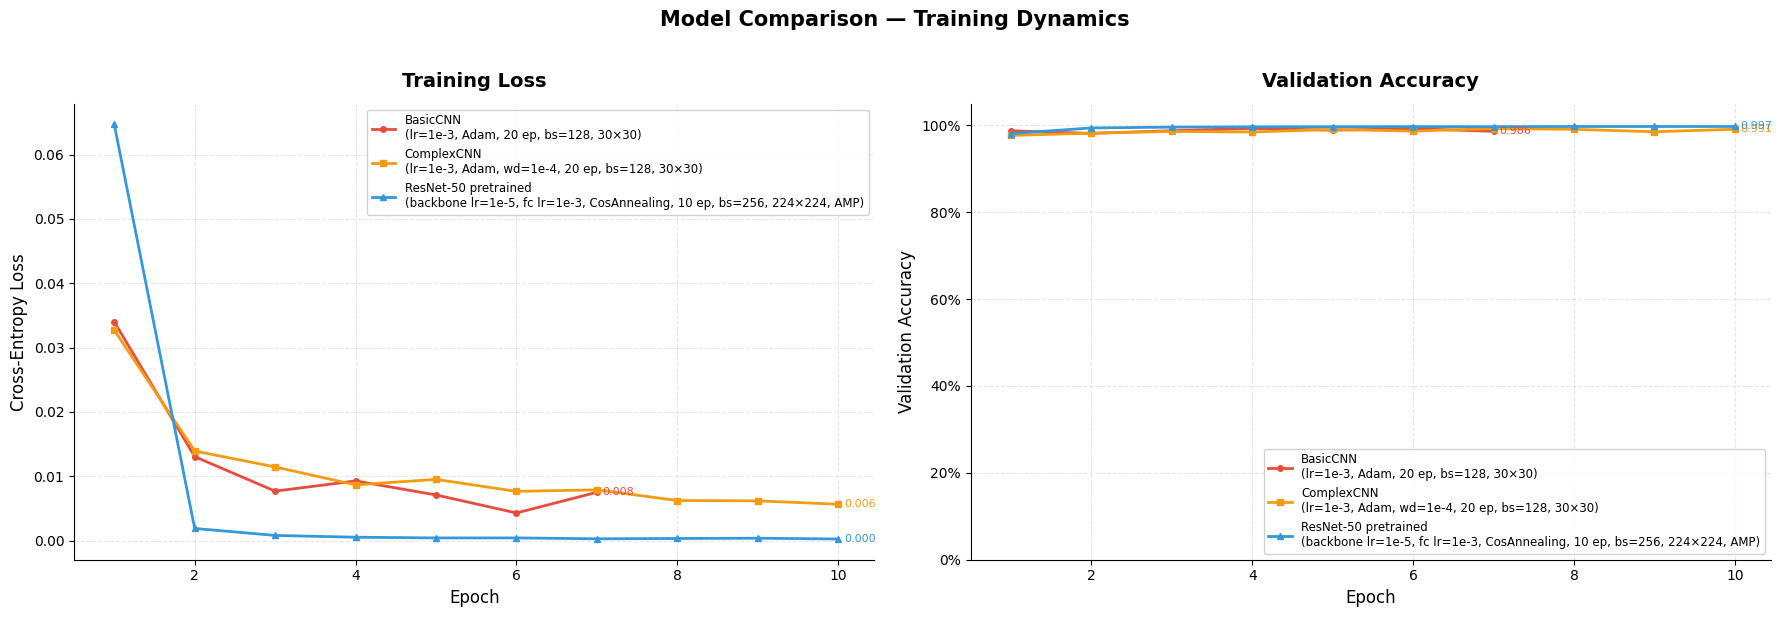

Saved → checkpoints/training_curves.png

Model         Epochs  Final Train Loss  Best Val Acc
──────────────────────────────────────────────────────
BasicCNN           7            0.0075        0.9930
ComplexCNN        10            0.0057        0.9927
ResNet-50         10            0.0003        0.9975


In [17]:
# ------------------------------------------------------------------
# Training Loss & Validation Accuracy — separate plots with
# model + hyperparameter legends
# ------------------------------------------------------------------

# Hyperparameter annotations per model
MODEL_META = {
    'BasicCNN': {
        'color':    COLORS[0],
        'marker':   'o',
        'ls':       '-',
        'label':    'BasicCNN\n(lr=1e-3, Adam, 20 ep, bs=128, 30×30)',
    },
    'ComplexCNN': {
        'color':    COLORS[1],
        'marker':   's',
        'ls':       '-',
        'label':    'ComplexCNN\n(lr=1e-3, Adam, wd=1e-4, 20 ep, bs=128, 30×30)',
    },
    'ResNet-50': {
        'color':    COLORS[2],
        'marker':   '^',
        'ls':       '-',
        'label':    'ResNet-50 pretrained\n(backbone lr=1e-5, fc lr=1e-3, CosAnnealing, 10 ep, bs=256, 224×224, AMP)',
    },
}

all_histories = {
    'BasicCNN':   basic_history,
    'ComplexCNN': complex_history,
    'ResNet-50':  resnet_history,
}

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(18, 6))

for name, hist in all_histories.items():
    m    = MODEL_META[name]
    eps  = range(1, len(hist['train_loss']) + 1)
    c, mk, ls, lbl = m['color'], m['marker'], m['ls'], m['label']

    # ── Plot 1: Training Loss ──────────────────────────────────────
    ax_loss.plot(eps, hist['train_loss'],
                 color=c, marker=mk, ls=ls, markersize=4,
                 linewidth=2, label=lbl)

    # ── Plot 2: Validation Accuracy ────────────────────────────────
    ax_acc.plot(eps, hist['val_acc'],
                color=c, marker=mk, ls=ls, markersize=4,
                linewidth=2, label=lbl)

    # Annotate final value
    ax_loss.annotate(f'{hist["train_loss"][-1]:.3f}',
                     xy=(len(hist['train_loss']), hist['train_loss'][-1]),
                     xytext=(4, 0), textcoords='offset points',
                     fontsize=8, color=c, va='center')
    ax_acc.annotate(f'{hist["val_acc"][-1]:.3f}',
                    xy=(len(hist['val_acc']), hist['val_acc'][-1]),
                    xytext=(4, 0), textcoords='offset points',
                    fontsize=8, color=c, va='center')

# ── Styling ────────────────────────────────────────────────────────
ax_loss.set_title('Training Loss', fontsize=14, fontweight='bold', pad=12)
ax_loss.set_xlabel('Epoch', fontsize=12)
ax_loss.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax_loss.legend(fontsize=8.5, loc='upper right',
               framealpha=0.9, edgecolor='#cccccc')
ax_loss.grid(True, alpha=0.3, linestyle='--')
ax_loss.set_xlim(left=0.5)
ax_loss.spines[['top', 'right']].set_visible(False)

ax_acc.set_title('Validation Accuracy', fontsize=14, fontweight='bold', pad=12)
ax_acc.set_xlabel('Epoch', fontsize=12)
ax_acc.set_ylabel('Validation Accuracy', fontsize=12)
ax_acc.set_ylim(0, 1.05)
ax_acc.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_acc.legend(fontsize=8.5, loc='lower right',
              framealpha=0.9, edgecolor='#cccccc')
ax_acc.grid(True, alpha=0.3, linestyle='--')
ax_acc.set_xlim(left=0.5)
ax_acc.spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison — Training Dynamics', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints' / 'training_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/training_curves.png')

# ── Summary table ──────────────────────────────────────────────────
print(f'\n{"Model":<12}  {"Epochs":>6}  {"Final Train Loss":>16}  {"Best Val Acc":>12}')
print('─' * 54)
for name, hist in all_histories.items():
    best_val = max(hist['val_acc'])
    print(f'{name:<12}  {len(hist["train_loss"]):>6}  '
          f'{hist["train_loss"][-1]:>16.4f}  {best_val:>12.4f}')


## 8. Logistic Regression Baseline

Two baselines establish performance floors:
1. **LR on raw pixels** — how much classification signal is in raw intensity alone
2. **LR on ComplexCNN features** — separates architecture value from classifier value

In [18]:
@torch.no_grad()
def collect_flat(loader, device):
    imgs_list, lbls_list = [], []
    for imgs, lbls in loader:
        imgs_list.append(imgs.view(imgs.size(0), -1).cpu().numpy())
        lbls_list.extend(lbls.numpy())
    return np.vstack(imgs_list), np.array(lbls_list)


@torch.no_grad()
def collect_features(model, loader, device):
    model.eval()
    feats_list, lbls_list = [], []
    for imgs, lbls in loader:
        feats_list.append(model.extract_features(imgs.to(device)).cpu().numpy())
        lbls_list.extend(lbls.numpy())
    return np.vstack(feats_list), np.array(lbls_list)


# Pixel LR
X_tr_px, y_tr = collect_flat(loaders_30['train'], device)
X_te_px, y_te = collect_flat(loaders_30['test'],  device)
print('Fitting LR on pixels...')
lr_px = LogisticRegression(max_iter=500, C=1.0, random_state=SEED, n_jobs=-1)
lr_px.fit(X_tr_px, y_tr)
print(f'  Pixel LR test acc: {lr_px.score(X_te_px, y_te):.4f}')

# ComplexCNN feature LR
print('Extracting ComplexCNN features...')
X_tr_f, _ = collect_features(complex_model, loaders_30['train'], device)
X_te_f, _ = collect_features(complex_model, loaders_30['test'],  device)
print('Fitting LR on CNN features...')
lr_feat = LogisticRegression(max_iter=300, C=1.0, random_state=SEED, n_jobs=-1)
lr_feat.fit(X_tr_f, y_tr)
print(f'  CNN-feature LR test acc: {lr_feat.score(X_te_f, y_te):.4f}')

Fitting LR on pixels...
  Pixel LR test acc: 0.9936
Extracting ComplexCNN features...
Fitting LR on CNN features...
  CNN-feature LR test acc: 0.2589


## 9. Full Evaluation — Test Set

All deep models are evaluated on the same held-out 15% test split using **eval transforms** (no augmentation).  Metrics: accuracy, per-class recall, macro F1, and macro AUC-ROC.

In [19]:
@torch.no_grad()
def run_inference(model, loader, device):
    model.eval()
    labels_list, preds_list, probs_list = [], [], []
    for imgs, lbls in loader:
        logits = model(imgs.to(device))
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        labels_list.extend(lbls.numpy())
        preds_list.extend(preds)
        probs_list.append(probs)
    return np.array(labels_list), np.array(preds_list), np.vstack(probs_list)


results = {}
for model_name, model, loaders in [
    ('BasicCNN',   basic_model,   loaders_30),
    ('ComplexCNN', complex_model, loaders_30),
    ('ResNet-50',  resnet_model,  loaders_224),
]:
    y_true, y_pred, y_prob = run_inference(model, loaders['test'], device)
    acc = (y_true == y_pred).mean()
    rpt = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                 output_dict=True, zero_division=0)
    y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    try:
        auc_score = roc_auc_score(y_bin, y_prob, average='macro', multi_class='ovr')
    except Exception:
        auc_score = float('nan')
    results[model_name] = dict(y_true=y_true, y_pred=y_pred, y_prob=y_prob,
                                acc=acc, report=rpt, auc=auc_score)
    print(f'{model_name:<12}  acc={acc:.4f}  macro_AUC={auc_score:.4f}')

BasicCNN      acc=0.9846  macro_AUC=0.9991
ComplexCNN    acc=0.9916  macro_AUC=0.9998
ResNet-50     acc=0.9974  macro_AUC=0.9980


In [20]:
# Per-class recall table
print(f'\n{"":<14}', end='')
for cn in CLASS_NAMES + ['macro F1']:
    print(f'{cn:>14}', end='')
print()
print('-' * (14 + 14 * (len(CLASS_NAMES) + 1)))

for name, res in results.items():
    rpt = res['report']
    print(f'{name:<14}', end='')
    for cn in CLASS_NAMES:
        print(f'{rpt.get(cn, {}).get("recall", 0):>14.4f}', end='')
    print(f'{rpt.get("macro avg", {}).get("f1-score", 0):>14.4f}')

# LR baselines
print()
for lr_name, lr_m, X_te, y_te_ref in [
    ('LR (pixels)',  lr_px,   X_te_px, y_te),
    ('LR (CNN-feat)',lr_feat, X_te_f,  y_te),
]:
    pred = lr_m.predict(X_te)
    rpt  = classification_report(y_te_ref, pred, target_names=CLASS_NAMES,
                                  output_dict=True, zero_division=0)
    print(f'{lr_name:<14}', end='')
    for cn in CLASS_NAMES:
        print(f'{rpt.get(cn, {}).get("recall", 0):>14.4f}', end='')
    print(f'{rpt.get("macro avg", {}).get("f1-score", 0):>14.4f}')


                        stop         yield    donotenter      macro F1
----------------------------------------------------------------------
BasicCNN              0.9841        0.9948        0.9883        0.9195
ComplexCNN            0.9915        0.9922        0.9942        0.9539
ResNet-50             0.9977        0.9948        0.9883        0.9842

LR (pixels)           0.9946        0.9765        0.9825        0.9602
LR (CNN-feat)         0.2543        0.3029        0.3801        0.1677


## 10. AUC-ROC Analysis

**ROC curves** plot True Positive Rate vs False Positive Rate across all thresholds (not just argmax).  For safety-critical classes, a high AUC ensures the model's confidence scores can be reliably thresholded — e.g., a downstream system might flag low-confidence predictions for human review.

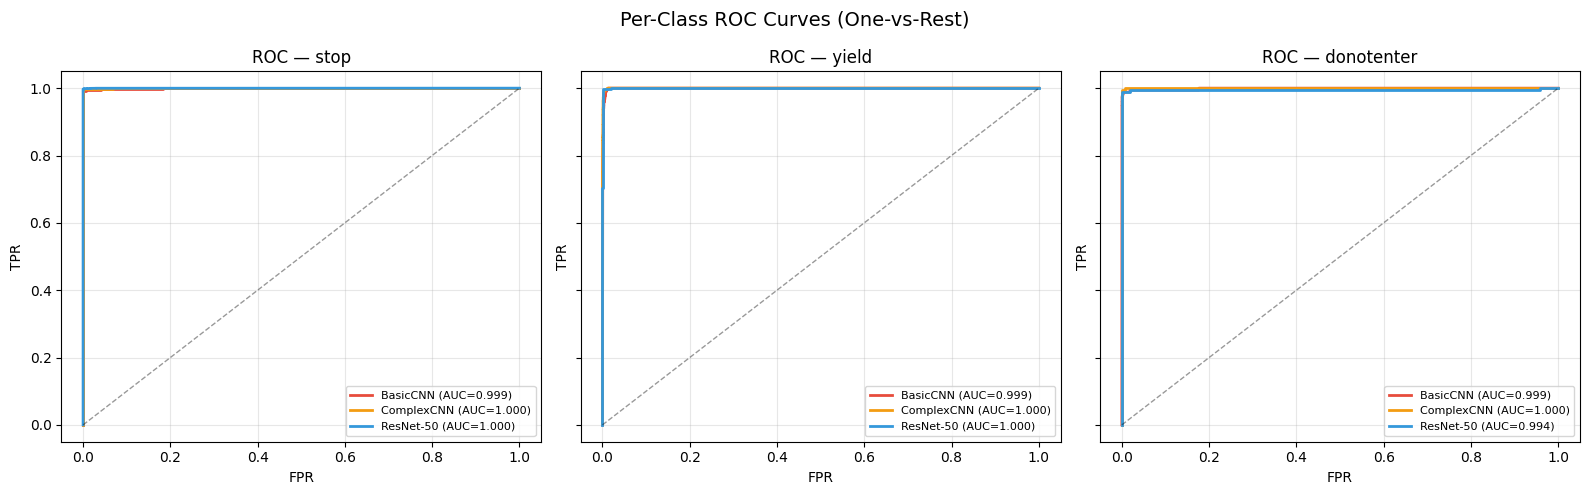

In [24]:
# Per-class ROC curves — one subplot per class
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 5), sharey=True)

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    ax = axes[cls_idx]
    for model_name, res in results.items():
        y_bin  = (res['y_true'] == cls_idx).astype(int)
        scores = res['y_prob'][:, cls_idx]
        if len(np.unique(y_bin)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_bin, scores)
        auc_val     = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=model_colors[model_name], lw=2,
                label=f'{model_name} (AUC={auc_val:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)
    ax.set_title(f'ROC — {cls_name}', fontsize=12)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Per-Class ROC Curves (One-vs-Rest)', fontsize=14)
plt.tight_layout()
plt.show()

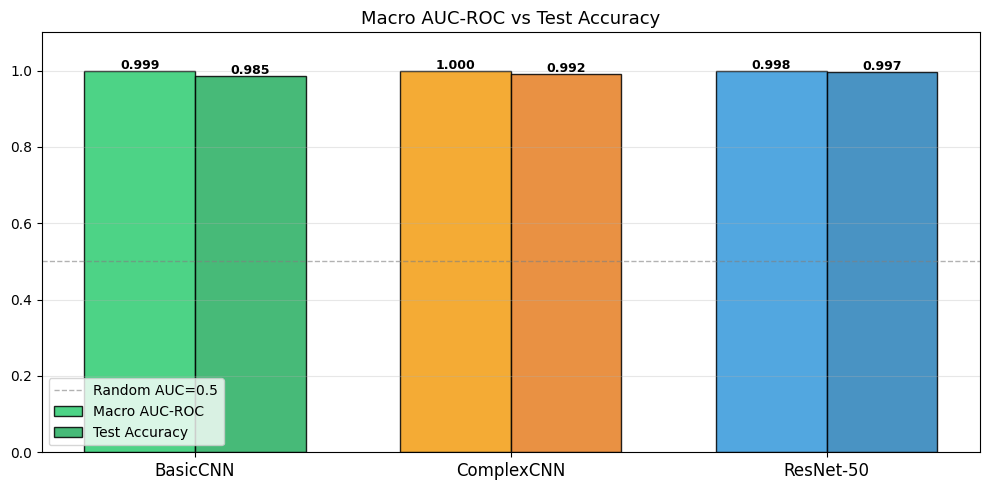

In [25]:
# Macro AUC-ROC + Test Accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names   = list(results.keys())
x, w    = np.arange(len(names)), 0.35

b1 = ax.bar(x - w/2, [results[n]['auc'] for n in names],  w,
            label='Macro AUC-ROC', color=['#2ECC71','#F39C12','#3498DB'],
            alpha=0.85, edgecolor='black')
b2 = ax.bar(x + w/2, [results[n]['acc'] for n in names],  w,
            label='Test Accuracy', color=['#27AE60','#E67E22','#2980B9'],
            alpha=0.85, edgecolor='black')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='gray', ls='--', lw=1, alpha=0.6, label='Random AUC=0.5')
ax.set_title('Macro AUC-ROC vs Test Accuracy', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Confusion Matrices

Row = true class, Column = predicted class.  Values are **row-normalised** (recall fractions).  Diagonal = correct.  Off-diagonal = error type — e.g. `stop → yield` is especially dangerous.

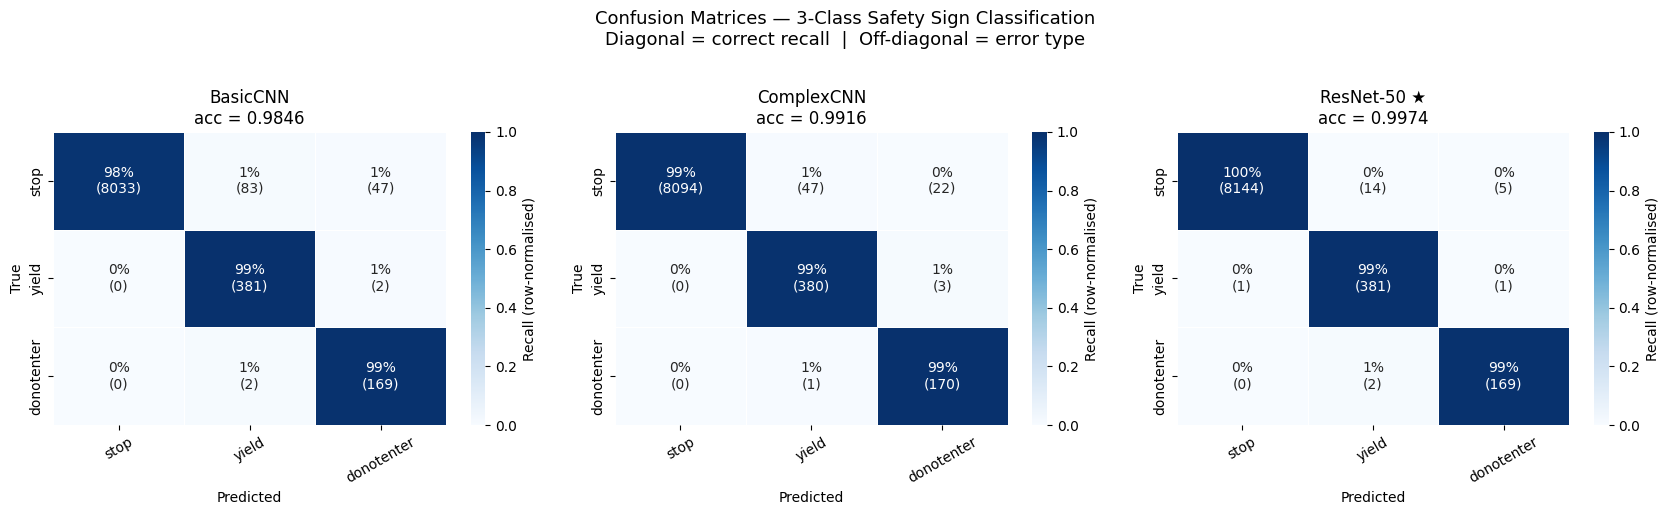

Saved → checkpoints/confusion_matrices.png

BasicCNN:
                 pred_stop  pred_yield  pred_donotenter
true_stop             8033          83               47
true_yield               0         381                2
true_donotenter          0           2              169

ComplexCNN:
                 pred_stop  pred_yield  pred_donotenter
true_stop             8094          47               22
true_yield               0         380                3
true_donotenter          0           1              170

ResNet-50:
                 pred_stop  pred_yield  pred_donotenter
true_stop             8144          14                5
true_yield               1         381                1
true_donotenter          0           2              169



In [26]:
# ------------------------------------------------------------------
# Confusion Matrices — normalised (recall) with raw counts
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm      = confusion_matrix(res['y_true'], res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    # Custom annotation: "pct%\n(count)"
    annot = np.array([[f'{cm_norm[r, c]:.0%}\n({cm[r, c]})'
                       for c in range(NUM_CLASSES)]
                      for r in range(NUM_CLASSES)])

    sns.heatmap(cm_norm, annot=annot, fmt='', ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cmap='Blues', vmin=0, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Recall (row-normalised)'})

    acc  = res['acc']
    best_tag = ' ★' if name == max(results, key=lambda n: results[n]['acc']) else ''
    ax.set_title(f'{name}{best_tag}\nacc = {acc:.4f}', fontsize=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — 3-Class Safety Sign Classification\n'
             'Diagonal = correct recall  |  Off-diagonal = error type',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints' / 'confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/confusion_matrices.png')

# Raw error summary for each model
print()
for name, res in results.items():
    cm = confusion_matrix(res['y_true'], res['y_pred'])
    print(f'{name}:')
    df = pd.DataFrame(cm, index=[f'true_{c}' for c in CLASS_NAMES],
                          columns=[f'pred_{c}' for c in CLASS_NAMES])
    print(df.to_string())
    print()


## 12. Per-Dataset Performance Breakdown

Aggregate test accuracy hides domain gaps.  Here we evaluate each model separately on each source to measure robustness to distribution shift (clean GTSRB vs noisy BDD100K).

In [27]:
# ------------------------------------------------------------------
# Per-source evaluation
# FilteredSubset built ONCE per source (not 3× per model).
# num_workers=0 for small datasets — avoids worker-spawn overhead
# that costs more than the inference itself.
# ------------------------------------------------------------------
per_ds    = {n: {} for n in results}
SMALL_DS  = 200   # threshold below which worker processes waste more time than they save

model_specs = [
    ('BasicCNN',   basic_model,   tf_eval_30),
    ('ComplexCNN', complex_model, tf_eval_30),
    ('ResNet-50',  resnet_model,  tf_eval_224),
]

for src_name, raw_ds in raw_datasets:
    n_match = sum(1 for _, l in raw_ds.samples if l in DOT_TO_3)
    if n_match == 0:
        continue

    # Build one FilteredSubset per (source, transform-size) — reuse across models
    ds_30  = FilteredSubset(raw_ds, set(DOT_TO_3.keys()), DOT_TO_3, tf_eval_30)
    ds_224 = FilteredSubset(raw_ds, set(DOT_TO_3.keys()), DOT_TO_3, tf_eval_224)

    for model_name, model, tf in model_specs:
        ds = ds_30 if tf is tf_eval_30 else ds_224
        if len(ds) == 0:
            per_ds[model_name][src_name] = (0.0, 0)
            continue
        nw = 0 if len(ds) < SMALL_DS else NUM_WORKERS
        loader = DataLoader(ds, batch_size=max(BATCH_SIZE, 64),
                            num_workers=nw, pin_memory=(device.type == 'cuda'))
        y_true, y_pred, _ = run_inference(model, loader, device)
        per_ds[model_name][src_name] = ((y_true == y_pred).mean(), len(ds))

all_srcs = sorted({s for r in per_ds.values() for s in r})
print(f'{"Model":<14}', end='')
for s in all_srcs:
    print(f'{s:>15}', end='')
print()
print('-' * (14 + 15 * len(all_srcs)))
for mname in results:
    print(f'{mname:<14}', end='')
    for s in all_srcs:
        acc, n = per_ds[mname].get(s, (float('nan'), 0))
        cell = f'{acc:.4f}({n})' if n > 0 else 'n/a'
        print(f'{cell:>15}', end='')
    print()


Model                 BDD100K            DOT     GTSRB_test    GTSRB_train           LISA
-----------------------------------------------------------------------------------------
BasicCNN          0.7530(502)      1.0000(3)   0.9267(1350)   0.9565(4050)  0.9893(53562)
ComplexCNN        0.7530(502)      1.0000(3)   0.9326(1350)   0.9560(4050)  0.9958(53562)
ResNet-50         0.7709(502)      0.3333(3)   0.9852(1350)   0.9963(4050)  0.9999(53562)


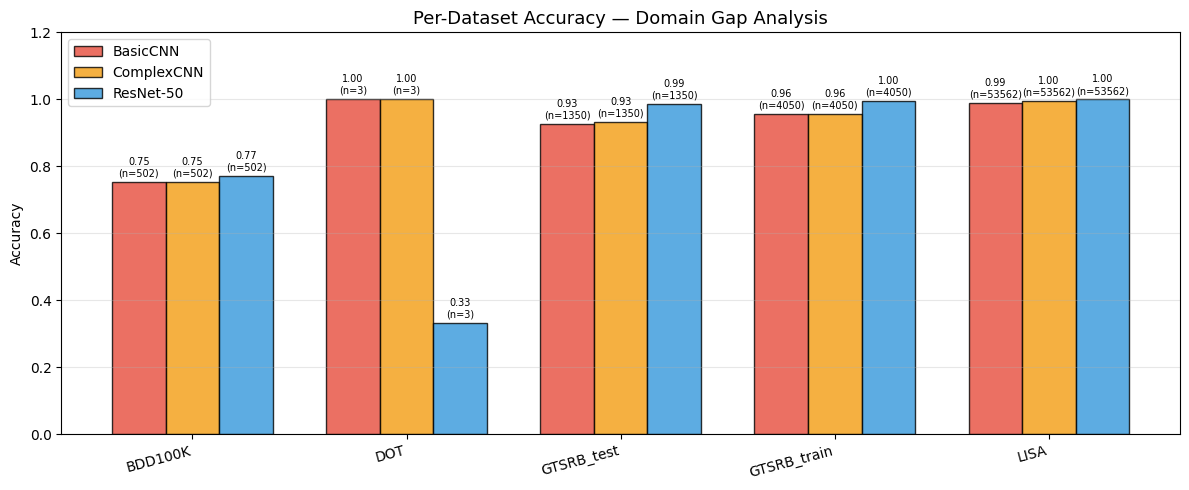

In [28]:
# Per-dataset bar chart
srcs_with_data = [s for s in all_srcs
                  if any(per_ds[m].get(s, (0, 0))[1] > 0 for m in results)]
x, w   = np.arange(len(srcs_with_data)), 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, (mname, color) in enumerate(model_colors.items()):
    accs = [per_ds[mname].get(s, (0, 0))[0] for s in srcs_with_data]
    ns   = [per_ds[mname].get(s, (0, 0))[1] for s in srcs_with_data]
    bars = ax.bar(x + i*w, accs, w, label=mname, color=color, alpha=0.8, edgecolor='black')
    for b, acc, n in zip(bars, accs, ns):
        if n > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                    f'{acc:.2f}\n(n={n})', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x + w)
ax.set_xticklabels(srcs_with_data, rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Accuracy')
ax.set_title('Per-Dataset Accuracy — Domain Gap Analysis', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11b. Confidence Calibration — ECE & Reliability Diagrams

**Expected Calibration Error (ECE)** measures whether a model's stated confidence
matches its empirical accuracy. A perfectly calibrated model that says *70% confident*
is correct exactly 70% of the time.

- ECE = 0 → perfect calibration
- ECE > 0.05 → overconfident or underconfident; unsafe for threshold-based alerts

The **reliability diagram** plots mean confidence (x) vs empirical accuracy (y) per bin.
Points above the diagonal → underconfident; below → overconfident.

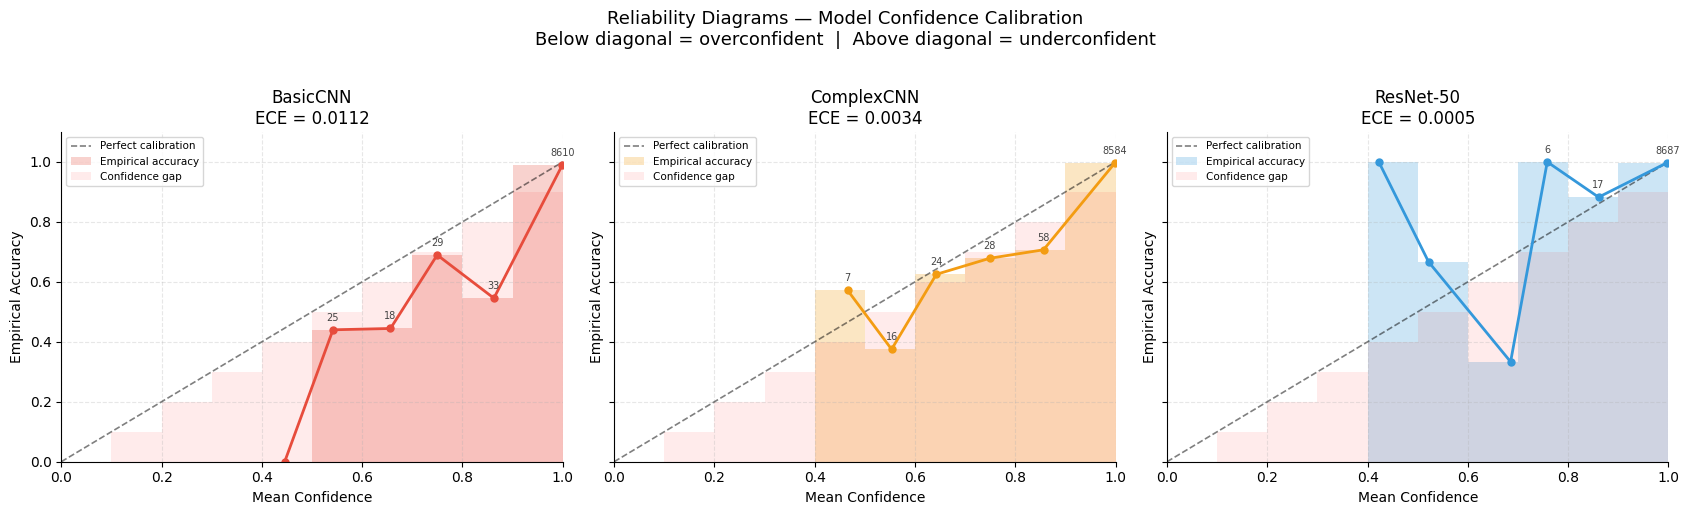

Saved → checkpoints/calibration.png

Model                ECE  Interpretation
───────────────────────────────────────────────────────
BasicCNN          0.0112  well-calibrated
ComplexCNN        0.0034  well-calibrated
ResNet-50         0.0005  well-calibrated


In [29]:
# ------------------------------------------------------------------
# ECE + Reliability Diagrams
# ------------------------------------------------------------------
def compute_ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (uniform binning)."""
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies  = (predictions == y_true).astype(float)

    bins     = np.linspace(0, 1, n_bins + 1)
    ece      = 0.0
    bin_data = []   # (mean_conf, mean_acc, n)

    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        n    = mask.sum()
        if n == 0:
            bin_data.append((0.5 * (lo + hi), 0.0, 0))
            continue
        bin_conf = confidences[mask].mean()
        bin_acc  = accuracies[mask].mean()
        ece     += (n / len(y_true)) * abs(bin_acc - bin_conf)
        bin_data.append((bin_conf, bin_acc, n))

    return ece, bins, bin_data


fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)

for ax, (name, res) in zip(axes, results.items()):
    ece_val, bins, bin_data = compute_ece(res['y_true'], res['y_prob'])
    confs = [d[0] for d in bin_data]
    accs  = [d[1] for d in bin_data]
    ns    = [d[2] for d in bin_data]
    color = model_colors[name]

    # Perfect calibration reference
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.5, label='Perfect calibration')

    # Gap fill (overconfidence shading)
    ax.bar(bins[:-1], accs, width=np.diff(bins),
           align='edge', alpha=0.25, color=color, label='Empirical accuracy')
    ax.bar(bins[:-1], bins[:-1], width=np.diff(bins),
           align='edge', alpha=0.08, color='red', label='Confidence gap')

    # Calibration curve
    valid = [i for i, n in enumerate(ns) if n > 0]
    ax.plot([confs[i] for i in valid], [accs[i] for i in valid],
            'o-', color=color, lw=2, markersize=5)

    # Annotate bin counts
    for i in valid:
        if ns[i] > 5:
            ax.text(confs[i], accs[i] + 0.03, str(ns[i]),
                    ha='center', fontsize=7, color='#444444')

    ax.set_title(f'{name}\nECE = {ece_val:.4f}', fontsize=12)
    ax.set_xlabel('Mean Confidence', fontsize=10)
    ax.set_ylabel('Empirical Accuracy', fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.1)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=7.5, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Reliability Diagrams — Model Confidence Calibration\n'
             'Below diagonal = overconfident  |  Above diagonal = underconfident',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints' / 'calibration.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/calibration.png')

# ECE summary
print(f'\n{"Model":<14}  {"ECE":>8}  {"Interpretation":}')
print('─' * 55)
ece_interp = lambda e: 'well-calibrated' if e < 0.05 else ('moderate' if e < 0.10 else 'poorly calibrated')
for name, res in results.items():
    ece_val, _, _ = compute_ece(res['y_true'], res['y_prob'])
    print(f'{name:<14}  {ece_val:>8.4f}  {ece_interp(ece_val)}')


## 13. Model Comparison Summary Table

In [30]:
param_map = {'BasicCNN': count_params(basic_model)[0],
             'ComplexCNN': count_params(complex_model)[0],
             'ResNet-50':  count_params(resnet_model)[0]}
time_map  = {'BasicCNN': basic_time, 'ComplexCNN': complex_time, 'ResNet-50': resnet_time}
bval_map  = {'BasicCNN':   max(basic_history['val_acc']),
             'ComplexCNN': max(complex_history['val_acc']),
             'ResNet-50':  max(resnet_history['val_acc'])}
ep_map    = {'BasicCNN': 20, 'ComplexCNN': 20, 'ResNet-50': 10}

rows = []
for name, res in results.items():
    rpt = res['report']
    rows.append({
        'Model':          name,
        'Input':          '30×30' if name != 'ResNet-50' else '224×224',
        'Pretrained':     'ImageNet' if name == 'ResNet-50' else 'No',
        'Params':         f"{param_map[name]:,}",
        'Epochs':         ep_map[name],
        'Train time':     f"{time_map[name]/60:.1f} min",
        'Best Val Acc':   f"{bval_map[name]:.4f}",
        'Test Acc':       f"{res['acc']:.4f}",
        'Macro F1':       f"{rpt.get('macro avg',{}).get('f1-score',0):.4f}",
        'AUC-ROC':        f"{res['auc']:.4f}",
        'stop recall':    f"{rpt.get('stop',{}).get('recall',0):.4f}",
        'yield recall':   f"{rpt.get('yield',{}).get('recall',0):.4f}",
        'dne recall':     f"{rpt.get('donotenter',{}).get('recall',0):.4f}",
    })

# LR baselines
for lr_name, lr_m, X_te, y_te_ref in [
    ('LR (pixels)',  lr_px,   X_te_px, y_te),
    ('LR (CNN-feat)',lr_feat, X_te_f,  y_te),
]:
    pred = lr_m.predict(X_te)
    prob = lr_m.predict_proba(X_te)
    rpt  = classification_report(y_te_ref, pred, target_names=CLASS_NAMES,
                                  output_dict=True, zero_division=0)
    y_bin = label_binarize(y_te_ref, classes=list(range(NUM_CLASSES)))
    try:
        lr_auc = roc_auc_score(y_bin, prob, average='macro', multi_class='ovr')
    except Exception:
        lr_auc = float('nan')
    acc = (y_te_ref == pred).mean()
    rows.append({
        'Model': lr_name, 'Input': '30×30 flat', 'Pretrained': '—',
        'Params': 'sklearn', 'Epochs': '—', 'Train time': '—',
        'Best Val Acc': '—',
        'Test Acc':  f'{acc:.4f}',
        'Macro F1':  f"{rpt.get('macro avg',{}).get('f1-score',0):.4f}",
        'AUC-ROC':   f'{lr_auc:.4f}',
        'stop recall':  f"{rpt.get('stop',{}).get('recall',0):.4f}",
        'yield recall': f"{rpt.get('yield',{}).get('recall',0):.4f}",
        'dne recall':   f"{rpt.get('donotenter',{}).get('recall',0):.4f}",
    })

df = pd.DataFrame(rows).set_index('Model')
print(df.to_string())
df

                    Input Pretrained      Params Epochs Train time Best Val Acc Test Acc Macro F1 AUC-ROC stop recall yield recall dne recall
Model                                                                                                                                        
BasicCNN            30×30         No     314,819     20    1.8 min       0.9930   0.9846   0.9195  0.9991      0.9841       0.9948     0.9883
ComplexCNN          30×30         No     455,939     20    4.1 min       0.9927   0.9916   0.9539  0.9998      0.9915       0.9922     0.9942
ResNet-50         224×224   ImageNet  23,514,179     10  128.4 min       0.9975   0.9974   0.9842  0.9980      0.9977       0.9948     0.9883
LR (pixels)    30×30 flat          —     sklearn      —          —            —   0.9936   0.9602  0.9991      0.9946       0.9765     0.9825
LR (CNN-feat)  30×30 flat          —     sklearn      —          —            —   0.2589   0.1677  0.4881      0.2543       0.3029     0.3801


,Input,Pretrained,Params,Epochs,Train time,Best Val Acc,Test Acc,Macro F1,AUC-ROC,stop recall,yield recall,dne recall
Model,,,,,,,,,,,,
BasicCNN,30×30,No,"314,819",20,1.8 min,0.9930,0.9846,0.9195,0.9991,0.9841,0.9948,0.9883
ComplexCNN,30×30,No,"455,939",20,4.1 min,0.9927,0.9916,0.9539,0.9998,0.9915,0.9922,0.9942
ResNet-50,224×224,ImageNet,"23,514,179",10,128.4 min,0.9975,0.9974,0.9842,0.9980,0.9977,0.9948,0.9883
LR (pixels),30×30 flat,—,sklearn,—,—,—,0.9936,0.9602,0.9991,0.9946,0.9765,0.9825
LR (CNN-feat),30×30 flat,—,sklearn,—,—,—,0.2589,0.1677,0.4881,0.2543,0.3029,0.3801


## 14. Error Analysis

Misclassified images from the best model reveal failure modes: extreme blur (BDD100K dashcam), partial occlusion, or ambiguous crops where the 30×30 resolution loses shape cues.

ResNet-50: 23 errors / 8717 test samples


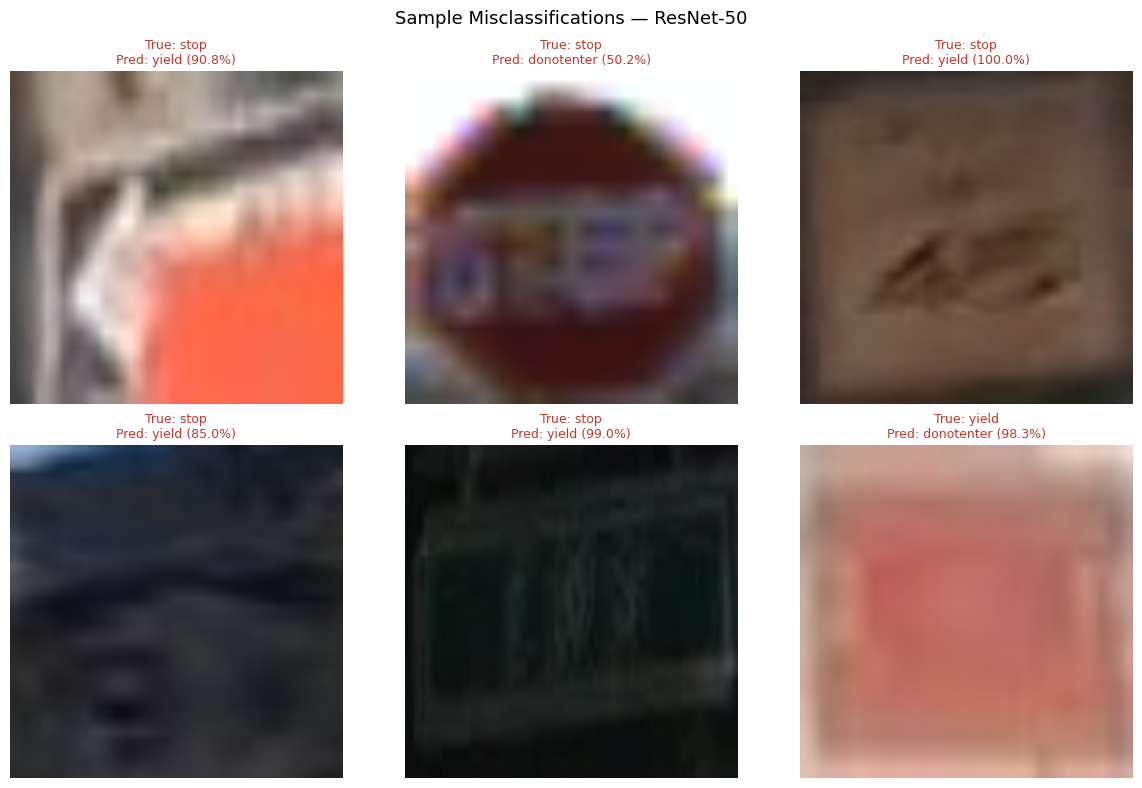

In [31]:
best_name = max(results, key=lambda n: results[n]['acc'])
best_res  = results[best_name]
wrong_idx = np.where(best_res['y_true'] != best_res['y_pred'])[0]
print(f'{best_name}: {len(wrong_idx)} errors / {len(best_res["y_true"])} test samples')

if len(wrong_idx) == 0:
    print('No errors — perfect test accuracy!')
else:
    loader = loaders_30['test'] if best_name != 'ResNet-50' else loaders_224['test']
    all_imgs = torch.cat([imgs for imgs, _ in loader])

    rng     = np.random.default_rng(SEED)
    sample  = rng.choice(wrong_idx, min(6, len(wrong_idx)), replace=False)
    _MEAN   = np.array([0.485, 0.456, 0.406])
    _STD    = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i, ax in enumerate(axes.flat):
        if i >= len(sample):
            ax.axis('off')
            continue
        idx   = sample[i]
        img   = np.clip(all_imgs[idx].permute(1,2,0).numpy() * _STD + _MEAN, 0, 1)
        true_ = CLASS_NAMES[best_res['y_true'][idx]]
        pred_ = CLASS_NAMES[best_res['y_pred'][idx]]
        conf  = best_res['y_prob'][idx, best_res['y_pred'][idx]]
        ax.imshow(img)
        ax.set_title(f'True: {true_}\nPred: {pred_} ({conf:.1%})', fontsize=9, color='#C0392B')
        ax.axis('off')

    plt.suptitle(f'Sample Misclassifications — {best_name}', fontsize=13)
    plt.tight_layout()
    plt.show()